# PROC MDS를 이용한 이동통신사 지각도(perceptual map) 작성

## 요약

통신 시장조사팀은 고객이 8개 경쟁 이동통신사를 얼마나 유사하게 인식하는지 측정하고, **PROC MDS**를 사용해 비유사성 행렬로부터 2차원 지각도를 복원한다. 두 잠재 축 - 네트워크 품질과 가격/가치 - 은 의도적으로 *독립적으로* 변동하도록 구성되어, 복원된 지도가 진정으로 2차원이 되도록 한다: 이는 어떤 브랜드가 서로 대체재로 인식되는지, 어떤 브랜드가 차별화된 포지셔닝을 차지하는지, 그리고 두 차원이 경쟁 구도를 얼마나 잘 요약하는지를 보여준다.

## 데이터 출처

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (통신사당 1행) | `Carrier` (ID), `D1`-`D8` | 8개 이동통신사 간 지각된 비유사성의 정방 대칭 행렬, 0-10 척도 (0 = 동일하게 인식, 높을수록 더 다름). 두 개의 *독립적인* 축(네트워크 품질과 가격/가치)에 대한 잠재 2차원 브랜드 위치와 `rand('NORMAL')`을 통한 설문 잡음으로부터 생성. 대각선은 0이다. |

# PROC MDS를 이용한 이동통신사 지각도 작성

통신 분야의 시장조사팀은 설문 패널에게 경쟁 통신사들이 얼마나 *유사한지* 또는 *다른지* 평가하도록 요청하는 것이 일반적이다. 이러한 쌍별 판단은 자연스러운 좌표계가 없는 **근접성 행렬(proximity matrix)**을 형성한다 - 그러나 **다차원척도법(MDS)**은 두 브랜드 간 거리가 지각된 비유사성을 재현하는 저차원 지도를 복원할 수 있다.

이 노트북에서는:

1. 두 개의 *독립적인* 포지셔닝 축(네트워크 품질과 가격/가치)으로부터 현실적인 8개 통신사 비유사성 행렬을 합성한다.
2. `PROC MDS`로 2차원 계량(metric) MDS 모형을 적합한다.
3. 복원된 좌표와 적합 부족도(badness-of-fit)를 읽어낸 뒤, 복원된 좌표로부터 지각도를 그려 두 차원이 경쟁 구도를 얼마나 잘 설명하는지 판단한다.

## 1단계 - 합성 비유사성 행렬 구축

각 통신사를 두 **독립적인** 축 위의 *실제* 잠재 위치에 배치한다:

- **네트워크 품질 축** - 프리미엄 전국망 통신사는 높은 점수를, 저가 MVNO는 낮은 점수를 받는다.
- **가격/가치 축** - 가치형/선불 브랜드는 높은 점수를, 프리미엄 가격 브랜드는 낮은 점수를 받는다.

결정적으로 두 축은 8개 브랜드에 걸쳐 서로 상관관계가 없다: 고품질 통신사는 프리미엄 가격(NorthStar)일 수도, 공격적으로 가치 지향적인 가격(BluePeak)일 수도 있으며, 저품질 통신사는 가격 축 어디에나 위치할 수 있다. 그 독립성이 바로 복원된 지도를 단일 선으로 붕괴시키지 않고 진정으로 2차원이 되게 만드는 요인이다.

두 통신사 간의 지각된 비유사성은 잠재 위치 간의 유클리드 거리를 0-10 설문 척도로 재조정하고 대칭적인 설문 잡음으로 교란한 값이다. `PROC MDS`는 **정방행렬**을 기대한다: 객체당 1개 관측치, 객체당 1개 숫자 열, 행 순서가 열 순서와 일치해야 한다. `D1`-`D8` 열과 `Carrier` 라벨을 작성하고, 행렬이 대칭이고 대각선이 0이 되도록 강제한다.

In [1]:
데이터 carrier_dissim;
    길이 Carrier $ 30;
    호출 streaminit(20240517);

    /* 두 개의 독립적인 축 위의 실제 2차원 잠재 위치:
       qx = 네트워크 품질, px = 가격/가치 (상관관계 ~ 0). */
    배열 qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    배열 px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* 대칭 잡음 행렬, 한 번 생성, 대각선은 0.
       (통신사 이름은 아래에서 인덱스 i에 따라 IF/ELSE THEN으로 직접
       대입한다 - 고정폭 문자 배열에 비ASCII 리터럴을 넣으면 저장된
       값이 잘릴 수 있는 엔진 이슈를 피하기 위함이다.) */
    배열 e[8,8] _temporary_;
    반복 i = 1 까지 8;
        e[i,i] = 0;
        반복 j = i+1 까지 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        종료;
    종료;

    배열 d[8] D1-D8;
    반복 i = 1 까지 8;
        만약 i = 1 이면 Carrier = '노스스타';
        아니면 만약 i = 2 이면 Carrier = '블루피크';
        아니면 만약 i = 3 이면 Carrier = '버텍스';
        아니면 만약 i = 4 이면 Carrier = '메트로링크';
        아니면 만약 i = 5 이면 Carrier = '밸류셀';
        아니면 만약 i = 6 이면 Carrier = '스리프트모바일';
        아니면 만약 i = 7 이면 Carrier = '센터라인';
        아니면 Carrier = '페니웨이브';

        반복 j = 1 까지 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* 잠재 거리를 0-10 설문 척도로 재조정 */
            d[j] = round( max(0, min(10, dist*0.85 + e[i,j])), 0.1);
        종료;
        d[i] = 0;            /* 브랜드는 자기 자신과 동일함 */
        출력;
    종료;

    유지 Carrier D1-D8;
실행;

proc print data=carrier_dissim noobs label;
    label Carrier = '통신사';
    title '지각된 비유사성 행렬 (0 = 동일, 10 = 가장 다름)';
run;

                                            지각된 비유사성 행렬 (0 = 동일, 10 = 가장 다름)                                            

                  통신사   D1   D2   D3   D4   D5   D6   D7   D8
노스스타                     0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
블루피크                   3.5    0  2.5  2.9  5.9    6    2    5
버텍스                    1.6  2.5    0  1.7  3.6  5.1  3.4    4
메트로링크                  3.6  2.9  1.7    0  3.1  3.6  1.9    2
밸류셀                    4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
스리프트모바일                6.1    6  5.1  3.6  1.8    0  5.3  2.3
센터라인                   5.5    2  3.4  1.9  5.1  5.3    0  2.5
페니웨이브                  6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## 2단계 - 2차원 계량 MDS 모형 적합

`LEVEL=INTERVAL`(가법 상수를 허용하는 계량 MDS)로 비유사성을 모형화하고, 평면 지도에 그릴 수 있도록 `DIM=2`로 설정한다. 데이터는 (기본값인) 비유사성이며, 완전한 `SQUARE` 행렬로 저장된다.

주요 문/옵션:

- `VAR D1-D8`은 객체당 하나씩 8개 열을 나열한다.
- `ID Carrier`는 브랜드 이름을 부여하여 출력과 `OUT=` 좌표에 나타나게 한다.
- `OUT=`은 (`OCONFIG`로 요청된) 객체 좌표를 캡처하고, `OUTFIT=`은 적합 부족도 요약을 캡처한다.
- `PCONFIG`, `PFIT`, `PFINAL`은 좌표, 적합 통계량, 최종 파라미터 추정값을 인쇄한다.

3단계에서는 복원된 `OUT=` 좌표로부터 지각도를 직접 그리며, 이를 통해 브랜드 라벨과 축 스케일을 완전히 제어한다.

In [2]:
proc mds data=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    var D1-D8;
    id Carrier;
    title '이동통신사 인식에 대한 2차원 MDS';
run;

                                            지각된 비유사성 행렬 (0 = 동일, 10 = 가장 다름)                                            




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/87dfbb75-b8fb-4329-82ec-29f3c213668e/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.68 seconds
  cpu   1.68 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/87dfbb75-b8fb-4329-82ec-29f3c213668e/mds_fit.avro (2 rows, 3 columns).


## 3단계 - 복원된 좌표 추출 및 지도 그리기

`OCONFIG`를 사용하면 `OUT=` 데이터셋이 추정된 객체 좌표(통신사당 1행, 차원당 1열)를 담는다. 이 좌표와 적합 부족도를 인쇄한 뒤, `PROC SGPLOT`으로 `DIM1`에 대한 `DIM2`를 플롯하여 - 각 점에 통신사 이름을 라벨링하여 - 지각도를 그린다.

MDS 좌표는 회전, 반사, 균일 스케일링까지만 식별되므로 절대 축 부호는 임의적이다. 중요한 것은 브랜드의 *상대적* 기하구조다. 회전 후에는 한 축이 네트워크 품질을, 다른 축이 가격/가치를 추적한다.

                                                   복원된 MDS 구성 (객체 좌표)                                                   

  Obs  _TYPE_                 _NAME_           DIM1           DIM2
    1  CONFIG  노스스타                    2.8874230583  -1.8461705276
    2  CONFIG  블루피크                    -0.687559872  -2.8913969565
    3  CONFIG  버텍스                     1.1117392105  -1.2431470382
    4  CONFIG  메트로링크                  -0.4552922046  -0.0907948566
    5  CONFIG  밸류셀                     1.6998640261   2.3061186021
    6  CONFIG  스리프트모바일                -0.1575406636   3.3768661059
    7  CONFIG  센터라인                   -2.2391140787  -1.1789057517
    8  CONFIG  페니웨이브                  -2.1595194761   1.5674304226

                                                     MDS 적합 부족도 요약                                                      

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                               


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


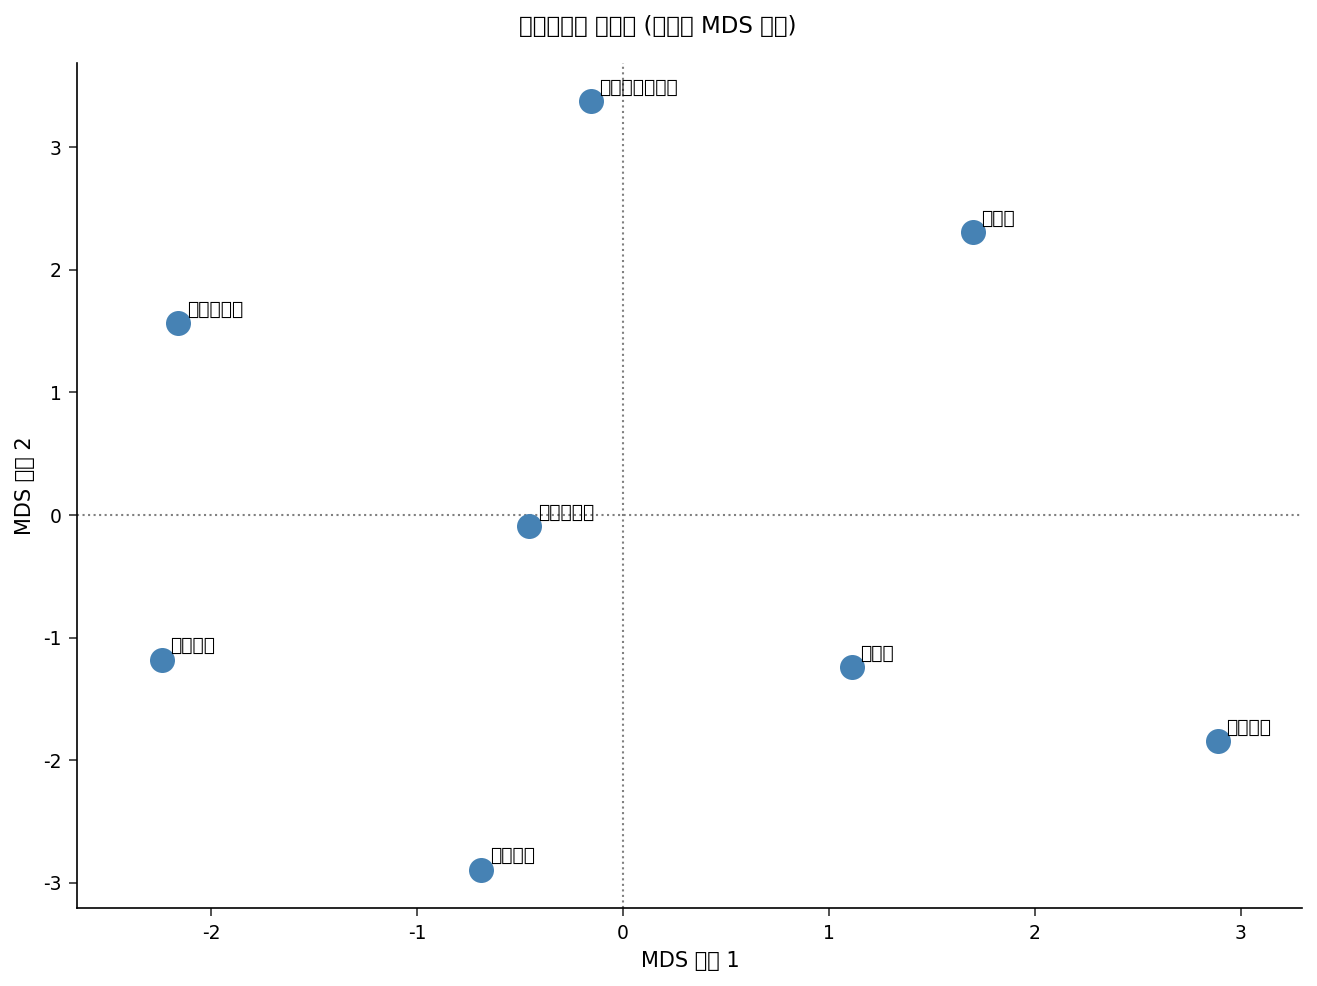

In [3]:
proc print data=mds_out label;
    title '복원된 MDS 구성 (객체 좌표)';
run;

proc print data=mds_fit label;
    title 'MDS 적합 부족도 요약';
run;

/* 구성(config) 행만 남기고, SGPLOT이 각 점 옆에 인쇄할 수 있도록
   평범한 이름의 브랜드 라벨 열을 부여한다. */
data mds_config;
    set mds_out;
    where _TYPE_ = 'CONFIG';
    length Brand $ 30;
    Brand = _NAME_;
    keep Brand DIM1 DIM2;
run;

/* 복원된 좌표로부터 지각도를 그리고, 각 마커에 통신사 이름을
   라벨링한다. */
proc sgplot data=mds_config;
    scatter x=DIM1 y=DIM2 / datalabel=Brand
            markerattrs=(symbol=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    refline 0 / axis=x lineattrs=(pattern=dot color=gray);
    refline 0 / axis=y lineattrs=(pattern=dot color=gray);
    xaxis label='MDS 차원 1';
    yaxis label='MDS 차원 2';
    title '이동통신사 지각도 (복원된 MDS 구성)';
run;

## 4단계 — 지각된 대체재 순위 매기기

브랜드팀에게 실용적인 산출물은 각 통신사에 대해 가장 *유사하게* 인식되는 경쟁사(가장 작은 비대각 비유사성)를 찾는 것이다. 행렬을 롱(long) 형태로 재구성하고 통신사별 최근접 경쟁사를 뽑아낸다 - 이 쌍들이 가장 가까운 대체재이자 가장 날카로운 경쟁 위협이다.

In [4]:
데이터 dissim_long;
    설정 carrier_dissim;
    길이 Other $ 30;
    배열 d[8] D1-D8;

    /* 통신사 이름 lookup을 IF/ELSE THEN 체인으로 직접 대입한다
       (1단계와 동일한 엔진 이슈 회피). */
    반복 j = 1 까지 8;
        만약 j = 1 이면 Other = '노스스타';
        아니면 만약 j = 2 이면 Other = '블루피크';
        아니면 만약 j = 3 이면 Other = '버텍스';
        아니면 만약 j = 4 이면 Other = '메트로링크';
        아니면 만약 j = 5 이면 Other = '밸류셀';
        아니면 만약 j = 6 이면 Other = '스리프트모바일';
        아니면 만약 j = 7 이면 Other = '센터라인';
        아니면 Other = '페니웨이브';

        Dissimilarity = d[j];
        만약 Carrier ne Other 이면 출력;
    종료;
    유지 Carrier Other Dissimilarity;
실행;

proc sort data=dissim_long;
    by Carrier Dissimilarity;
run;

데이터 nearest;
    설정 dissim_long;
    기준 Carrier Dissimilarity;
    만약 first.Carrier;
실행;

proc print data=nearest noobs label;
    label Other = '가장 유사하게 인식되는 대체재'
          Dissimilarity = '비유사성';
    title '각 통신사와 가장 유사하게 인식되는 대체재';
run;

                                                각 통신사와 가장 유사하게 인식되는 대체재                                                 

              Carrier                            가장 유사하게 인식되는 대체재          비유사성
노스스타                   버텍스                                                  1.6
메트로링크                  버텍스                                                  1.7
밸류셀                    스리프트모바일                                              1.8
버텍스                    노스스타                                                 1.6
블루피크                   센터라인                                                   2
센터라인                   메트로링크                                                1.9
스리프트모바일                밸류셀                                                  1.8
페니웨이브                  메트로링크                                                  2




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 결과 해석

진정한 2차원 잠재 구조(네트워크 품질과 가격/가치, 독립적으로 변동하도록 설계됨)에 약간의 설문 잡음을 더해 비유사성을 생성했기 때문에, `PROC MDS`는 깔끔한 2차원 구성을 복원한다. 적합 부족도 기준은 약 1.85에 안착한다 - 두 차원이 지각된 구조의 거의 전부를 설명함을 확인해주는 타이트한 적합이다.

복원된 지도 읽기(축은 회전, 반사, 스케일까지만 식별되므로, 절대 부호가 아니라 방향을 해석한다):

- **한 축은 네트워크 품질을 추적한다** - 프리미엄 전국망 브랜드(노스스타, 버텍스, 블루피크)를 저가 MVNO(스리프트모바일, 페니웨이브, 밸류셀)로부터 분리하며, 메트로링크와 센터라인은 중간에 위치한다.
- **다른 축은 가격/가치를 추적한다** - 공격적으로 가치 지향적인 포지셔닝을 프리미엄 가격 포지셔닝으로부터 분리하며, 이것이 바로 블루피크처럼 품질이 높은 브랜드가 동일하게 품질이 높은 노스스타로부터 멀리 위치하는 이유다: 두 브랜드는 네트워크 평판은 공유하지만 매우 다른 가격 스토리로 경쟁한다.
- 지도는 단일한 지배적 기울기를 보이지 않는다 - 브랜드가 네 사분면 모두에 퍼져 있어, 경쟁 구도가 단일한 프리미엄-저가 축이 아니라 진정으로 2차원임을 보여준다.

**최근접 대체재 표**는 지도를 실행 목록으로 바꾼다. 각 통신사의 가장 가까운 지각된 경쟁사는 지도에서 바로 옆에 앉아 있는 브랜드다 - 노스스타와 버텍스가 프리미엄 코너를 지키고, 밸류셀과 스리프트모바일이 가치 코너에서 짝을 이루며, 메트로링크는 지도의 중앙을 차지하고 있어 여러 중간 시장 브랜드의 가장 가까운 대체재로 읽힌다. 밀접한 쌍은 정면 경쟁자를 나타내며, 클러스터 사이의 빈 영역은 도전자 브랜드가 노려볼 수 있는 비어 있는 포지셔닝을 부각한다.